# Bluestock Mutual Fund — Performance Analytics

Notebook:`04_performance_analytics.ipynb`  · 

This notebook turns the cleaned NAV history into risk-and-return analytics. Each section follows the
same flow — **load → compute → validate → analyse & visualise → insight** — and every chart is
exported to `reports/charts/`.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [16]:
df_nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
df_nav_history['date'] = pd.to_datetime(df_nav_history['date'])
df_nav_history = df_nav_history.sort_values(['amfi_code', 'date']).reset_index(drop=True)

print("Data loaded. Shape:", df_nav_history.shape)

Data loaded. Shape: (64320, 3)


## 1. Daily Return Analysis

Daily NAV history for all AMFI schemes is converted into **daily returns** — the workhorse input for
every downstream risk metric (volatility, drawdown, Sharpe). For each scheme the return on day *t* is

$$ r_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1 $$


In [17]:
df_nav_history['daily_return'] = df_nav_history.groupby('amfi_code')['nav'].pct_change()
df_nav_history['amfi_code'] = df_nav_history['amfi_code'].astype('int')
print("Daily Returns Summary:")
print(df_nav_history['daily_return'].describe())
print(df_nav_history.head())


Daily Returns Summary:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


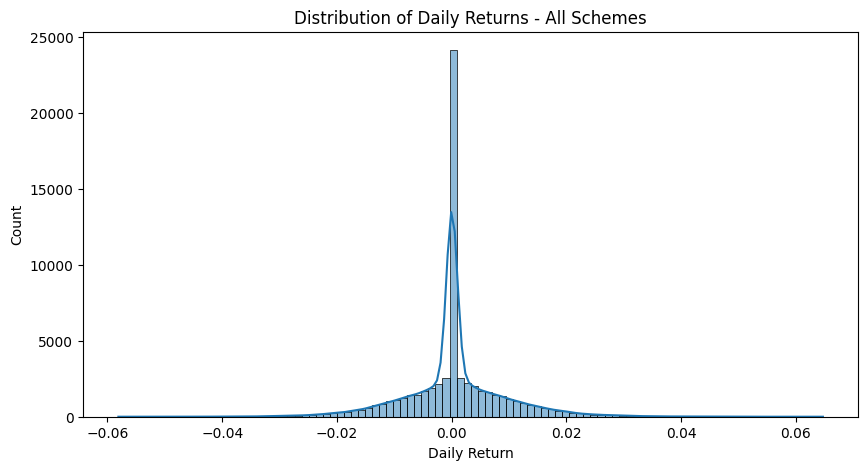

In [18]:
# Distribution check
plt.figure(figsize=(10,5))
sns.histplot(df_nav_history['daily_return'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns - All Schemes")
plt.xlabel("Daily Return")
plt.show()

## 2. CAGR Analysis

**Compound Annual Growth Rate (CAGR)** annualises a fund's total NAV growth over a horizon:

$$ \text{CAGR} = \left(\frac{\text{NAV}_{end}}{\text{NAV}_{start}}\right)^{1/\text{years}} - 1 $$

We compute **1-year, 3-year and 5-year** CAGR per scheme directly from NAV levels (not from the daily
returns). Three rules keep the numbers honest:

- **Actual dates, not assumed years.** For each horizon we anchor `NAV_end` at the scheme's last
  observed date, target `end_date − N years`, take the **first available NAV on or after** that target,
  and divide by the *actual* elapsed years (`days / 365.25`) — never a hard-coded `N`.
- **Insufficient history → `NaN`.** If the scheme's earliest NAV is later than the target start date,
  the horizon cannot be covered and CAGR is left as `NaN`. **No 5-year value is fabricated.**
- The reason for every `NaN` is documented in the validation step and the closing insights.

In [22]:
from dateutil.relativedelta import relativedelta

HORIZONS = [1, 3, 5]  # years


def cagr(group, years):
    """CAGR for one scheme over `years`, using actual dates. NaN if history is too short."""
    group = group.dropna(subset=["nav"])
    end_date = group["date"].max()
    end_nav = group.loc[group["date"].idxmax(), "nav"]
    first_date = group["date"].min()

    target_start = end_date - relativedelta(years=years)

    # Not enough history to cover the full window -> do not fabricate a value
    if first_date > target_start:
        available = (end_date - first_date).days / 365.25
        return np.nan

    # First NAV at or after the target start date (actual trading day, not the calendar target)
    eligible = group[group["date"] >= target_start]
    start_row = eligible.loc[eligible["date"].idxmin()]
    elapsed = (end_date - start_row["date"]).days / 365.25

    return (end_nav / start_row["nav"]) ** (1 / elapsed) - 1

cagr_data = []
for code, group in df_nav_history.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': code,
        'CAGR_1yr': cagr(group, 1),
        'CAGR_3yr': cagr(group, 3),
        'CAGR_5yr': cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_data)
cagr_df['amfi_code'] = cagr_df['amfi_code'].astype('int')

In [26]:
print("Top 10 Funds by 3-Year CAGR:")
print(cagr_df.sort_values('amfi_code', ascending=True).head(10).round(4))

Top 10 Funds by 3-Year CAGR:
   amfi_code  CAGR_1yr  CAGR_3yr  CAGR_5yr
0     100016   -0.0223    0.0129       NaN
1     100025    0.0371    0.0392       NaN
2     100033    0.5328    0.3243       NaN
3     101206    0.4796    0.2896       NaN
4     101207   -0.2400   -0.0415       NaN
5     101208    0.0724    0.0631       NaN
6     102885    0.2022    0.1966       NaN
7     102886   -0.1681   -0.0077       NaN
8     102887    0.1359    0.2555       NaN
9     118632    0.3401    0.2265       NaN


## 3. Sharpe Ratio Analysis

The **Sharpe ratio** measures return earned *per unit of risk* — how much a fund beats the risk-free
rate for each unit of volatility it takes on:

$$ \text{Sharpe} = \frac{R_{annual} - R_f}{\sigma_{annual}} $$

The **Sortino ratio** is a refinement of Sharpe that penalises only *harmful* volatility. Where Sharpe
divides excess return by total volatility (upside **and** downside), Sortino divides by **downside
deviation** — the volatility of negative-return days alone:

$$ \text{Sortino} = \frac{R_{annual} - R_f}{\sigma_{downside}} $$

This rewards funds whose volatility comes mostly from *upside* swings rather than losses. Using the same
**Rf = 6.5%** and **252** trading days:

- **Annual return** = mean daily return × 252
- **Downside deviation** = std of the *negative* daily returns × √252
- **Annual volatility** = std of daily returns × √252
- **Sharpe** = (annual return − Rf) / annual volatility
- **Sortino** = (annual return − Rf) / downside deviation

A higher Sharpe is better; a *negative* Sharpe means the fund returned **less than the risk-free rate**
over the window.

In [39]:
Rf_daily  = 0.065 / 252  

def sharpe_ratio(group):
    return (group.mean() - Rf_daily ) / group.std() * np.sqrt(252) if group.std() != 0 else np.nan

def sortino_ratio(group):
    downside = group[group < 0]
    return (group.mean() - Rf_daily ) / downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan

df_nav_ratio_compiled = df_nav_history.groupby('amfi_code')['daily_return'].agg([sharpe_ratio, sortino_ratio]).reset_index()

print(df_nav_ratio_compiled.sort_values('sharpe_ratio', ascending=False).head(10))

    amfi_code  sharpe_ratio  sortino_ratio
34     148567      1.068224       1.490739
30     120843      0.965561       1.479503
36     148569      0.919047       1.352815
25     120505      0.883256       1.285843
19     119551      0.860977       1.291483
38     149323      0.832885       1.167793
2      100033      0.808268       1.144216
9      118632      0.758851       1.098880
16     119094      0.730547       1.055284
3      101206      0.717409       1.063909


## 4. Alpha and Beta Analysis

**Beta** and **alpha** come from regressing each fund's daily returns on the market benchmark
(**Nifty 100**):

$$ r_{fund} = \alpha_{daily} + \beta \cdot r_{benchmark} + \varepsilon $$

- **Beta** = regression *slope* — the fund's sensitivity to market moves (β=1 moves with the market,
  β>1 amplifies it, β<1 dampens it).
- **Alpha** = regression *intercept* annualised (× 252) — return earned *independently* of the market.
- **R²** tells us how much of the fund's variance the benchmark explains; **p-value** tells us whether
  the beta is statistically distinguishable from zero.

We use `scipy.stats.linregress` per scheme on the dates the fund and benchmark share.

In [31]:
from scipy.stats import linregress


df_bm = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')
TRADING_DAYS = 252

df_benchmark_NIFTY100 = df_bm[df_bm['index_name'] == "NIFTY100"].copy()  # NIFTY100
df_benchmark_NIFTY100 = df_benchmark_NIFTY100.sort_values('date')
df_benchmark_NIFTY100['bench_return'] = df_benchmark_NIFTY100['close_value'].pct_change()

df_benchmark_NIFTY100['date'] = pd.to_datetime(df_benchmark_NIFTY100['date'])
benchmark = df_benchmark_NIFTY100[["date", "bench_return"]].dropna()


alpha_beta = []
for code, g in df_nav_history.groupby("amfi_code"):
    merged = (
        g[["date", "daily_return"]]
        .merge(benchmark, on="date", how="inner")
        .dropna(subset=["daily_return", "bench_return"])
    )
    reg = linregress(merged["bench_return"], merged["daily_return"])
    alpha_beta.append({
        "amfi_code": code,
        "alpha": reg.intercept * TRADING_DAYS,   # annualised
        "beta": reg.slope,
    })

df_alpha_beta = pd.DataFrame(alpha_beta)
print(df_alpha_beta.head())

df_alpha_beta["alpha_rank"] = df_alpha_beta["alpha"].rank(ascending=False, method="first").astype(int)
df_alpha_beta["beta_rank"] = df_alpha_beta["beta"].rank(ascending=False, method="first").astype(int)

df_alpha_beta.to_csv('../data/processed/alpha_beta.csv')

print(df_alpha_beta.sort_values('alpha', ascending=False).head(10))

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
    amfi_code     alpha      beta  alpha_rank  beta_rank
21     119598  0.303370 -0.023196           1         30
39     149324  0.300579  0.011455           2         13
25     120505  0.292636  0.000549           3         19
36     148569  0.282704  0.018134           4          9
30     120843  0.273305 -0.022830           5         29
2      100033  0.271954  0.005104           6         16
34     148567  0.269838  0.023684           7          7
38     149323  0.265986 -0.002523           8         24
16     119094  0.260767 -0.066265           9         39
19     119551  0.232010 -0.031751          10         33


## 5. Maximum Drawdown Analysis

**Maximum drawdown** is the worst peak-to-trough decline an investor would have suffered while holding a
fund — the single most intuitive measure of downside pain. For each scheme we track the **running peak**
NAV and the drawdown beneath it:

$$ \text{drawdown}_t = \frac{\text{NAV}_t}{\text{running peak}_t} - 1 $$

For the deepest drawdown of each fund we record the **peak date** (where the decline began), the
**trough date** (deepest point), the **recovery date** (first day NAV regains the prior peak, if it
ever does), and the **duration in days**. Funds still below their peak at the end of the data have **no
recovery date** — we do not assume one.

In [35]:
def max_dd(group):
    cmax = group.cummax()
    drawdown = group / cmax -1
    return drawdown.min()

In [36]:
max_drawdown = df_nav_history.groupby('amfi_code')['nav'].apply(max_dd).reset_index(name='Max_Drawdown')

# Rank 1 = most negative (deepest) drawdown
max_drawdown["drawdown_rank"] = (
    max_drawdown["Max_Drawdown"].rank(ascending=True, method="first").astype(int)
)

print(max_drawdown.sort_values('Max_Drawdown').head(10))
print(max_drawdown.head())

    amfi_code  Max_Drawdown  drawdown_rank
22     119599     -0.525742              1
17     119095     -0.516778              2
4      101207     -0.354469              3
39     149324     -0.311719              4
21     119598     -0.287060              5
7      102886     -0.280011              6
0      100016     -0.247344              7
29     120842     -0.240035              8
11     118634     -0.233449              9
15     119093     -0.217514             10
   amfi_code  Max_Drawdown  drawdown_rank
0     100016     -0.247344              7
1     100025     -0.043083             37
2     100033     -0.162172             21
3     101206     -0.112916             32
4     101207     -0.354469              3


## 7. Fund Scorecard (0–100)

The final step distils every metric from Sections 1–6 into a single **0–100 composite score** so funds
can be ranked head-to-head. Five dimensions are blended with fixed weights:

| Weight | Dimension | Source | Better when |
|-------:|-----------|--------|-------------|
| **30%** | 3-year CAGR | `cagr_comparison.csv` | higher |
| **25%** | Sharpe ratio | `sharpe_rankings.csv` | higher |
| **20%** | Alpha | `alpha_beta.csv` | higher |
| **15%** | Expense ratio *(inverse)* | `01_fund_master.csv` | **lower** |
| **10%** | Maximum drawdown *(inverse)* | `max_drawdown.csv` | **smaller / less negative** |

**Method.** Each fund is ranked **1 = best** on every dimension (the two *inverse* dimensions are ranked
so that low expense and shallow drawdown earn rank 1). Each rank is converted to a 0–100 score with

$$ \text{score} = 100 \times \frac{N - \text{rank}}{N - 1} \quad\Rightarrow\quad \text{rank }1 = 100,\; \text{rank }N = 0 $$

then combined as `fund_score = 0.30·return + 0.25·sharpe + 0.20·alpha + 0.15·expense + 0.10·drawdown`.

In [43]:
master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

scorecard = (
    master[["amfi_code", "scheme_name", "category", "plan", "expense_ratio_pct"]]
    .merge(cagr_df[["amfi_code", "CAGR_3yr"]], on="amfi_code")
    .merge(df_nav_ratio_compiled[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(df_alpha_beta[["amfi_code", "alpha"]], on="amfi_code")
    .merge(max_drawdown[["amfi_code", "Max_Drawdown"]], on="amfi_code")
)

N = len(scorecard)
scorecard.head()

,amfi_code,scheme_name,category,plan,expense_ratio_pct,CAGR_3yr,sharpe_ratio,alpha,Max_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,1.54,0.304486,0.860977,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Direct,0.66,0.162634,0.648241,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,1.43,0.266631,0.711690,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Direct,0.72,-0.013371,-0.136178,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Regular,0.77,0.058390,-0.743099,0.056209,-0.043287


In [44]:
# rank 1 = best in every dimension
scorecard["return_rank"]   = scorecard["CAGR_3yr"].rank(ascending=False, method="first").astype(int)
scorecard["sharpe_rank"]   = scorecard["sharpe_ratio"].rank(ascending=False, method="first").astype(int)
scorecard["alpha_rank"]    = scorecard["alpha"].rank(ascending=False, method="first").astype(int)
scorecard["expense_rank"]  = scorecard["expense_ratio_pct"].rank(ascending=True, method="first").astype(int)   # inverse: low fee best
scorecard["drawdown_rank"] = scorecard["Max_Drawdown"].rank(ascending=False, method="first").astype(int)   # inverse: least-negative best

# Each rank ranges a clean 1..N
for col in ["return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]:
    assert sorted(scorecard[col]) == list(range(1, N + 1)), f"{col} must be 1..N"
scorecard[["scheme_name", "return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank"]].head()


,scheme_name,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank
0,SBI Bluechip Fund - Regular Plan - Growth,6,5,10,30,17
1,SBI Bluechip Fund - Direct Plan - Growth,23,14,15,4,11
2,SBI Small Cap Fund - Regular Plan - Growth,12,13,1,21,36
3,SBI Small Cap Fund - Direct Plan - Growth,38,31,36,5,40
4,SBI Magnum Gilt Fund - Regular Plan - Growth,32,35,34,9,5


In [48]:
WEIGHTS = {"return": 0.30, "sharpe": 0.25, "alpha": 0.20, "expense": 0.15, "drawdown": 0.10}

def rank_to_score(rank, n=N):
    """Linear rank -> 0..100 score (rank 1 = 100, rank n = 0)."""
    return 100 * (n - rank) / (n - 1)

for dim in WEIGHTS:
    scorecard[f"{dim}_score"] = rank_to_score(scorecard[f"{dim}_rank"])

scorecard["fund_score"] = sum(WEIGHTS[d] * scorecard[f"{d}_score"] for d in WEIGHTS)
scorecard["overall_rank"] = scorecard["fund_score"].rank(ascending=False, method="first").astype(int)
scorecard = scorecard.sort_values("overall_rank").reset_index(drop=True)

print(f"Weights sum to {sum(WEIGHTS.values()):.2f}")
print(f"fund_score range: {scorecard['fund_score'].min():.2f} - {scorecard['fund_score'].max():.2f}")
scorecard[["overall_rank", "scheme_name", "category", "fund_score"]].head(10)


Weights sum to 1.00
fund_score range: 12.82 - 85.90


,overall_rank,scheme_name,category,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,85.897436
1,2,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.435897
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,81.538462
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.641026
4,5,ICICI Pru Bluechip Fund - Direct - Growth,Equity,78.846154
5,6,Axis Midcap Fund - Regular - Growth,Equity,77.692308
6,7,SBI Bluechip Fund - Regular Plan - Growth,Equity,73.717949
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,72.820513
8,9,SBI Small Cap Fund - Regular Plan - Growth,Equity,67.179487
9,10,ABSL Frontline Equity Fund - Regular - Growth,Equity,66.923077


In [50]:

fund_scorecard = scorecard[[
    "amfi_code", "scheme_name", "category",
    "return_rank", "sharpe_rank", "alpha_rank", "expense_rank", "drawdown_rank",
    "fund_score", "overall_rank",
]].copy()

fund_scorecard["fund_score"] = fund_scorecard["fund_score"].round(2)

fund_scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)

fund_scorecard.head(10)


,amfi_code,scheme_name,category,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,2,1,7,23,8,85.90,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,5,4,3,15,25,82.44,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,7,2,5,22,13,81.54,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,4,7,6,16,20,80.64,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,3,11,13,12,12,78.85,5
5,119094,Axis Midcap Fund - Regular - Growth,Equity,1,9,9,17,28,77.69,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,6,5,10,30,17,73.72,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,8,3,4,37,21,72.82,8
8,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,12,13,1,21,36,67.18,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,9,10,12,36,9,66.92,10


## Benchmark comparison chart

In [52]:
benchmarks = pd.read_csv('../data/processed/10_benchmark_indices_cleaned.csv')
benchmarks['date'] = pd.to_datetime(benchmarks['date'])

# Get top 5 funds 
top5 = scorecard.sort_values("overall_rank").head(5).reset_index(drop=True)

# Prepare data for last 3 years
END_DATE = df_nav_history["date"].max()
START_DATE = END_DATE - pd.DateOffset(years=3)
print(f"3-year window: {START_DATE.date()} -> {END_DATE.date()}")
print("\nTop 5 funds by overall_rank:")
for _, r in top5.iterrows():
    print(f"  #{int(r['overall_rank'])}  {r['scheme_name']}  (score {r['fund_score']})")

## Build normalized performance series

def normalize(frame, value_col):
    """Rebase a sorted time series to 100 at its first value."""
    f = frame.sort_values("date").copy()
    f["normalized"] = f[value_col] / f[value_col].iloc[0] * 100
    return f


# Funds (in Top-5 order)
fund_series = {}
for _, r in top5.iterrows():
    g = df_nav_history[(df_nav_history["amfi_code"] == r["amfi_code"]) & (df_nav_history["date"] >= START_DATE)]
    fund_series[r["scheme_name"]] = normalize(g[["date", "nav"]], "nav")

# Benchmarks
bench_series = {}
for name in ["NIFTY50", "NIFTY100"]:
    b = benchmarks[(benchmarks["index_name"] == name) & (benchmarks["date"] >= START_DATE)]
    bench_series[name] = normalize(b[["date", "close_value"]], "close_value")

print("Series built (rows · first date · last date):")
for name, s in {**fund_series, **bench_series}.items():
    print(f"  {name[:42]:42} {len(s):5d}  {s['date'].min().date()} -> {s['date'].max().date()}")

3-year window: 2023-05-29 -> 2026-05-29

Top 5 funds by overall_rank:
  #1  Mirae Asset Large Cap Fund - Regular - Growth  (score 85.89743589743588)
  #2  ICICI Pru Midcap Fund - Regular - Growth  (score 82.43589743589743)
  #3  Kotak Flexicap Fund - Regular - Growth  (score 81.53846153846152)
  #4  HDFC Mid-Cap Opportunities Fund - Regular - Growth  (score 80.64102564102562)
  #5  ICICI Pru Bluechip Fund - Direct - Growth  (score 78.84615384615385)
Series built (rows · first date · last date):
  Mirae Asset Large Cap Fund - Regular - Gro  1097  2023-05-29 -> 2026-05-29
  ICICI Pru Midcap Fund - Regular - Growth    1097  2023-05-29 -> 2026-05-29
  Kotak Flexicap Fund - Regular - Growth      1097  2023-05-29 -> 2026-05-29
  HDFC Mid-Cap Opportunities Fund - Regular   1097  2023-05-29 -> 2026-05-29
  ICICI Pru Bluechip Fund - Direct - Growth   1097  2023-05-29 -> 2026-05-29
  NIFTY50                                      785  2023-05-29 -> 2026-05-29
  NIFTY100                            

In [53]:
all_series = {**fund_series, **bench_series}

# 1) Alignment: common start/end
starts = {s["date"].min() for s in all_series.values()}
ends = {s["date"].max() for s in all_series.values()}
print(f"Shared start date : {len(starts) == 1}  ({min(starts).date()})")
print(f"Shared end date   : {len(ends) == 1}  ({max(ends).date()})")

# 2) Missing values + correct rebasing
miss = sum(int(s["normalized"].isna().sum()) for s in all_series.values())
bases_ok = all(np.isclose(s["normalized"].iloc[0], 100) for s in all_series.values())
print(f"Missing normalized values : {miss}  (expected 0)")
print(f"All series start at 100    : {bases_ok}")
assert miss == 0 and bases_ok, "Series must be complete and rebased to 100"

# 3) Benchmark coverage vs the fund calendar
fund_days = len(next(iter(fund_series.values())))
bench_days = len(bench_series["NIFTY100"])
fund_dates = set(next(iter(fund_series.values()))["date"])
common = len(fund_dates & set(bench_series["NIFTY100"]["date"]))
print(f"\nFund trading days (window)      : {fund_days}")
print(f"NIFTY100 trading days (window)  : {bench_days}")
print(f"Dates shared by fund & NIFTY100 : {common}  ({common / fund_days:.0%} of fund calendar)")
print("\nAll benchmark-comparison validations passed.")

Shared start date : True  (2023-05-29)
Shared end date   : True  (2026-05-29)
Missing normalized values : 0  (expected 0)
All series start at 100    : True

Fund trading days (window)      : 1097
NIFTY100 trading days (window)  : 785
Dates shared by fund & NIFTY100 : 785  (72% of fund calendar)

All benchmark-comparison validations passed.


Saved chart -> ../reports/benchmark comparison chart.png


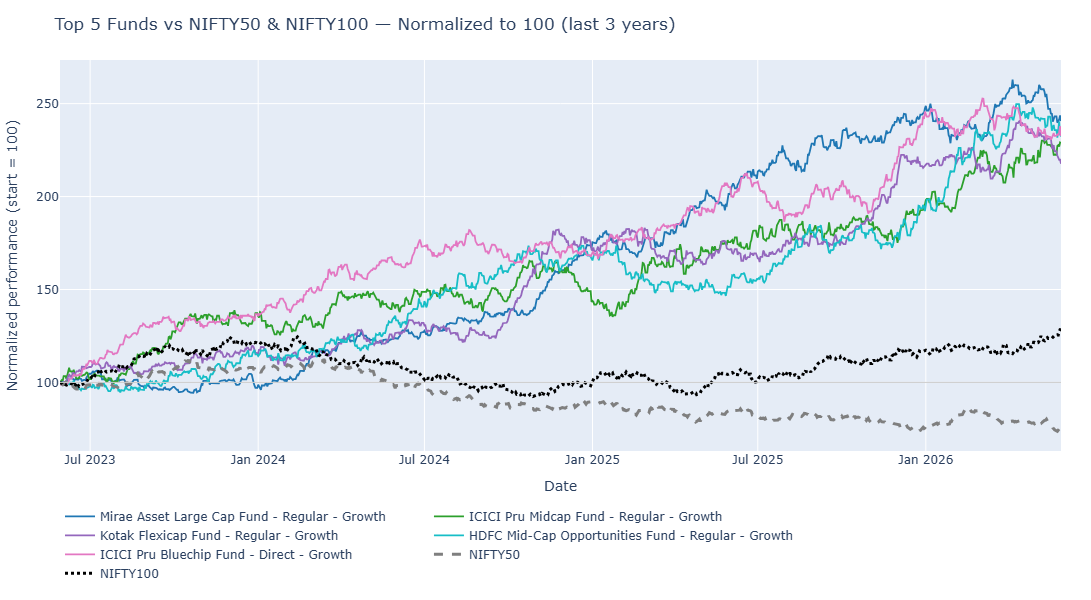

In [55]:
import plotly.graph_objects as go
import plotly.io as pio
fig = go.Figure()

fund_palette = ["#1f77b4", "#2ca02c", "#9467bd", "#17bec7", "#e377c2"]
for (name, s), color in zip(fund_series.items(), fund_palette):
    fig.add_trace(go.Scatter(x=s["date"], y=s["normalized"], mode="lines",
                             name=name, line=dict(color=color, width=1.8)))

bench_styles = {"NIFTY50": ("#7f7f7f", "dash"), "NIFTY100": ("#000000", "dot")}
for name, s in bench_series.items():
    color, dash = bench_styles[name]
    fig.add_trace(go.Scatter(x=s["date"], y=s["normalized"], mode="lines",
                             name=name, line=dict(color=color, width=3, dash=dash)))

fig.add_hline(y=100, line=dict(color="#cccccc", width=1))
fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100 — Normalized to 100 (last 3 years)",
    xaxis_title="Date", yaxis_title="Normalized performance (start = 100)",
    legend=dict(orientation="h", yanchor="bottom", y=-0.35, xanchor="left", x=0),
    width=1000, height=600, margin=dict(l=60, r=30, t=60, b=120),
)

BENCH_CHART = "../reports/benchmark comparison chart.png"
fig.write_image(BENCH_CHART, scale=2)   # static export via kaleido
print(f"Saved chart -> {BENCH_CHART}")

fig   # interactive embed

# Insights


##### All figures are the actual values computed above over the 3-year window 2023-05-29 → 2026-05-29; series rebased to 100 at the start.

##### Best performer. Mirae Asset Large Cap Fund (Regular) leads with a +140.6% total return — fittingly, the same fund that topped the Section 7 scorecard, so the composite ranking and the raw 3-year performance agree. ICICI Pru Bluechip Direct (+132.6%) and HDFC Mid-Cap Opportunities (+132.3%) follow closely, with ICICI Pru Midcap (+128.8%) and Kotak Flexicap (+117.6%) rounding out the five. The pack is tightly bunched (a ~23-point spread over three years).


##### Benchmark outperformance. Every one of the Top 5 comfortably beat NIFTY100 (total return +28.5%): excess returns range from +89.1% (Kotak Flexicap) to +112.1% (Mirae Large Cap). Against NIFTY50, which fell −25.0% over the same window, the outperformance is even more extreme (+140 to +165 points). On its face this says the selected funds delivered enormous market-beating alpha — but see the limitation below before reading it that way.

##### Benchmark underperformance. None of the Top 5 underperformed NIFTY100 — unsurprising given they were selected as the highest-scoring funds, which introduces obvious survivorship/selection bias into this particular comparison. The only "underperformer" on the chart is NIFTY50 itself, which lagged NIFTY100 by −53.5 points — an impossible divergence between two overlapping large-cap indices in real markets (see below).

##### Relative consistency. The five funds tracked each other closely and stayed above both benchmarks for essentially the entire window, with no large rotations of leadership — consistent with their uniformly high scorecard ranks. The benchmarks, by contrast, diverged wildly from each other, so the "consistency" visible here is a property of the funds relative to an erratic reference, not evidence of a stable market backdrop.